# **CUSTOM LOSS FUNCTIONS AND BACKTEST STATISTICS IN TENSORFLOW-KERAS**

## **1. INTRODUCTION**

In this notebook, we illustrate how to build custom loss functions when training deep learning models in TensorFlow-Keras. So far, we have trained our models using loss functions that measure the ability of the models to predict the variation in the training (or validation) set. However, this might not be the appropriate strategy in financial settings. Most of the time, we use our models to develop investment strategies whose performance metrics are defined in terms of risk-adjusted returns and other variables. The fact that a model yields a greater out-of-sample $R^2$ than other models does not necessarily mean that it will lead to better strategies in terms of standard metrics such as the Sharpe ratio. 

This notebook provides some guidelines on how to build custom losses that allow for keeping track of the trading performance of the model while training and backtesting a model in a Walk Forward method, as introduced in lesson 2. The aim is that, after reading and analyzing this notebook, you can build loss functions that are tailored to the applications that you may encounter in the future.

Before proceeding, we load all the required libraries and the data that we will exploit in this notebook. We use the same information that we exploited in lesson 2's notebook.

In [1]:
# %%
import numpy as np
import pandas as pd
import tensorflow as tf

# %%
# ====================================================
name = "Kraken_BTCUSD_60_3Q2022"

df = pd.read_csv(name + ".csv")

df["unix"] = pd.to_numeric(df["unix"])
df["date"] = pd.to_datetime(df["unix"], unit="s")

2025-05-26 12:50:46.550595: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-26 12:50:46.602301: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-26 12:50:47.975789: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = df[["date", "close", "volume", "trades"]]

In [3]:
df["Ret"] = df["close"].pct_change()
df["year"] = df["date"].dt.year

In [4]:
del df["close"]
df = df.loc[(df["year"] >= 2022)]
df["Ret"] = df["Ret"].fillna(0)
df["volume"] = df["volume"].fillna(0)
df["trades"] = df["trades"].fillna(0)

In [5]:
df = df.reindex(
    columns=[
        "date",
        "Ret",
        "volume",
        "trades",
        "year",
        "month",
        "day",
        "week",
        "weekday",
        "hour",
    ]
)
df = df[["date", "Ret"]]

n_lags = 24 * 15

for i in range(1, n_lags + 1):
    name = "Ret_" + str(i)
    df[name] = df["Ret"].shift(i)

df["Ret4_i"] = df["Ret"].rolling(4).apply(lambda x: 100 * (np.prod(1 + x / 100) - 1))
df["Ret4"] = df["Ret4_i"].shift(-4)
df["Output"] = df["Ret4"]

del df["Ret4"]
del df["Ret4_i"]

df = df.dropna()

/tmp/ipykernel_44/3839557224.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df["Ret"].shift(i)
/tmp/ipykernel_44/3839557224.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df["Ret"].shift(i)
/tmp/ipykernel_44/3839557224.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy(

In [6]:
X, y = df.iloc[:, 2:-1], df.iloc[:, -1]
print(X.shape, y.shape)

(6188, 360) (6188,)


## **2. DEFINING CUSTOM LOSSES AND BACKTEST STATISTICS IN TENSORFLOW-KERAS**

While the TensorFlow-Keras libraries contain many useful in-built loss functions for general machine learning projects, sometimes, we need to implement some modifications or implement a new loss function tailored to our particular application. Let's learn how to do that. Generally, any function (or *callable*) with the signature

```
loss_fn(y_true, y_pred) 
```
and that generates a loss can be passed to ``compile()`` as a loss function. Both inputs are tensors with dimension ```(batch_size, number of outputs)```. 

For instance, we can define a custom MSE loss function as follows
```
def custom_mse(y_true, y_pred): 
    # calculating squared difference between target and predicted values 
    loss0 = tf.square(y_pred - y_true)  # dimension (batch_size, number of outputs)
    loss1 = tf.reduce_sum(loss0, axis=-1) # dimension (batch_size, )
    return loss1
```
and then pass it to our model
```
model.compile(loss=custom_mse, optimizer='adam')
```
In the definition of ```custom_mse```, the line ```loss = tf.reduce_sum(y_pred - y_true, axis=-1)``` takes into account that the model may generate several outputs. Such line can be replaced by ```loss = tf.reduce_mean(y_pred - y_true, axis=-1)``` without affecting the optimization process.

Below, we are going to train a regression model, with an MLP, to predict the returns of Bitcoin. Despite training a regression model, we still may be interested in tracking the ability of the model to predict the sign of returns, as in a classification model. For this, we can define a custom accuracy metric from the predictions of the model and the actual realizations of returns:  

In [7]:
def custom_metric_acc(y_true, y_pred):
    acc = tf.reduce_sum(
        tf.cast(tf.math.multiply(y_true, y_pred) > 0, tf.int32)
    ) / tf.size(y_pred)
    return acc

Sometimes, our loss functions include some parameter that is independent from the trainable parameters of the model. To allow this, we need to define a *wrapper function* that includes the parameter of interest as an argument and that also nests the loss function of interest. 

For instance, suppose that our model generates several outputs (that is, predictions), and we want to give some particular relevance to some of those outputs over others with a predetermined vector of weights. We can define the wrapper function that includes as argument the vector of weights, as follows:
```
def wrapper(w)
  def custom_mse(y_true, y_pred): 
      # calculating squared difference between target and predicted values 
      loss = tf.square(y_pred - y_true)  # dimension (batch_size, number of outputs)
      loss_w = tf.math.multiply(loss, w)
      loss_w_sum = tf.reduce_sum(loss_w, axis=-1) # dimension (batch_size, )
      return loss_w_sum
    return custom_mse
```
We can pass the wrapper function to the compile method, after specifying the vector of weights.
```
weights = [0.1, ..., 0.025]

model.compile(loss=wrapper(weights), optimizer='adam')
```

Instead of optimizing our model using the custom loss, we can also add it as an additional evaluation metric as follows:
```
model.compile(loss='mse', metrics = wrapper(weights), optimizer='adam')
```
This option also allows for using the custom metric in an early stopping callback. After training, we can evaluate the performance in the test sample using the evaluate() method:
```
model.evaluate(X_test, y_test, batch_size = n_test)
```
where we set ```batch_size``` equal to the size of the test sample to obtain a proper evaluation of the loss function over the whole test sample. This will give us the value of both the in-built MSE loss and the custom MSE loss in the test sample.

Keras offers a variety of in-built loss functions. It is of relevance that you get familiar with the computation of these losses as described in the [documentation](
https://keras.io/api/losses/) to understand potential tweaks that you may have to implement in your own applications. In particular, you should review the computation of the following losses:
1. Regression loss functions
  1. Mean Squared Error
  2. Mean Absolute Error
  3. Mean Squared Logarithmic Error
  4. Mean Absolute Percentage Error 
  5. Huber loss
  6. Poisson loss (for count data)
  
2. Classification loss functions
  1. Binary Cross-Entropy loss
  2. Hinge loss

<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

The block of code below computes the $R^2$ of a regression model using a prediction ```benchmark``` against which the model is compared. For instance, the out-of-sample $R^2$ usually exploits the sample mean returns in the training test as the ```benchmark```.  

In [8]:
def custom_metric_r2(benchmark):
    def r2(y_true, y_pred):
        return 1 - tf.math.reduce_sum(tf.square(y_true - y_pred)) / tf.math.reduce_sum(
            tf.square(y_true - benchmark)
        )

    return r2

Beyond metrics that estimate the predictive power of a model, we can build the metrics obtained from the trading strategies that are a byproduct of the trained models. Below, we define a Sharpe ratio function computed from a long-short strategy that is based on the predictions of the model, the actual returns in the data, and a symmetric prediction barrier. The prediction barrier sets the level of predicted returns that should trigger a long, short, or neutral position.

In [9]:
def positions(y_pred, pred_barrier):
    """
    This function determines the long-short position on an asset based
    on the signal (predicted returns) y_pred from a model.
    pred_barrier is the threshold prediction that determines the long/short
    position
    """
    positions_long = tf.where(y_pred > pred_barrier, 1.0, 0.0)
    positions_short = tf.where(y_pred < -pred_barrier, -1.0, 0.0)
    return tf.add(positions_long, positions_short)


def strategy_rets(y_true, y_pred, pred_barrier):
    """
    This function computes the time series of returns given the predictions, actual returns
    and threshold prediction
    """
    return tf.math.multiply(positions(y_pred, pred_barrier)[:, 0], y_true)


def custom_metric_sr(pred_barrier):
    """
    This function computes the annualized Sharpe Ratio from hourly return data
    """

    def sharpe_ratio(y_true, y_pred):
        strat_ret = strategy_rets(y_true, y_pred, pred_barrier)
        sr = tf.math.sqrt(24.0 * 365.0) * tf.math.divide(
            tf.reduce_mean(strat_ret), tf.math.reduce_std(strat_ret)
        )
        return sr

    return sharpe_ratio

One problem with the long-short strategy defined above is that the gradient of the loss function with respect to ```y_pred``` is zero everywhere (and not differentiable at ```pred_barrier```) and TensorFlow will have problems in efficiently training the model if such function is used as the model's loss. An alternative is to define a strategy whose position in the asset is, say, linear in the prediction. This can be interpreted as defining a managed strategy where we put a fraction $w$ of our wealth in an asset, and $w$ is an increasing function of ```y_pred```. We do this below by defining $w=y\_pred/scale$, where $scale$ can be a parameter that governs the sensitivity of the strategy to changes in the predicted return. For instance, $scale$ can measure risk aversion and be itself a function of a risk metric, such as the variance of returns ```y_true``` over the training sample.

In [10]:
def positions_managed(y_pred, scale):
    return tf.math.divide(y_pred, scale)


def strategy_rets_managed(y_true, y_pred, scale):
    return tf.math.multiply(positions_managed(y_pred, scale)[:, 0], y_true)


def custom_metric_sr_managed(scale):
    def sharpe_ratio(y_true, y_pred):
        strat_ret = strategy_rets_managed(y_true, y_pred, scale)
        sr = tf.math.sqrt(24.0 * 365.0) * tf.math.divide(
            tf.reduce_mean(strat_ret), tf.math.reduce_std(strat_ret)
        )
        return sr

    return sharpe_ratio

Other useful backtesting metrics are the [Maximum Drawdown](https://www.investopedia.com/terms/m/maximum-drawdown-mdd.asp#:~:text=A%20maximum%20drawdown%20(MDD)%20is,over%20a%20specified%20time%20period.) and the Time under Water. A drawdown is the maximum loss suffered by an investment between two consecutive High-watermarks (Running maxima). The Maximum Drawdown is then the maximum among those losses. The Maximum Time under Water determines the longest period of time between two High-watermarks. These measures are informative about a strategy's downside risk and the length and depth of losses before the strategy runs a profit.

*(Note: The functions below cannot be passed to ```compile()``` as loss functions because they make use of pandas, which cannot be interpreted by TensorFlow).*


In [11]:
def custom_metric_DD(pred_barrier):
    def maxdrawdown(y_true, y_pred):
        # compute series of drawdowns
        strat_ret = strategy_rets_managed(y_true, y_pred, pred_barrier)
        cum_ret = tf.math.cumprod(1 + strat_ret).numpy()
        df0 = pd.DataFrame(cum_ret, columns=["cum_ret"])
        df0["HWM"] = df0["cum_ret"].expanding().max()
        df1 = df0.groupby("HWM").min().reset_index()
        df1.columns = ["HWM", "min"]
        df1.index = df0["HWM"].drop_duplicates(keep="first").index
        df1 = df1[df1["HWM"] > df1["min"]]
        dd = 1 - df1["min"] / df1["HWM"]
        return np.max(dd)

    return maxdrawdown

In [12]:
def custom_metric_TuW(pred_barrier):
    def time_under_water(y_true, y_pred):
        # compute the time under water
        strat_ret = strategy_rets_managed(y_true, y_pred, pred_barrier)
        cum_ret = tf.math.cumprod(1 + strat_ret).numpy()
        df0 = pd.DataFrame(cum_ret, columns=["cum_ret"])
        df0["HWM"] = df0["cum_ret"].expanding().max()
        df1 = df0.groupby("HWM").min().reset_index()
        df1.columns = ["HWM", "min"]
        df1.index = df0["HWM"].drop_duplicates(keep="first").index
        df1 = df1[df1["HWM"] > df1["min"]]
        tuw = df1.index[1:] - df1.index[:-1]
        tuw = pd.Series(tuw, index=df1.index[:-1])
        return np.max(tuw)

    return time_under_water

## **3. SETTING UP AND TRAINING THE FORECASTING MODEL**

Below, we set up the forecasting model and walk forward. Different from the notebook in lesson 2, we set up the model as a regression problem and also keep track of some performance metrics of the resulting strategies over each test sample.

Notice that the backtesting metrics defined above will return tensors with dimension ```batch_size``` where all elements will be the same. Then, it is important to set the batch size equal to the size of the test sample in the call to ```model.evaluate()```. Otherwise, we would not get the correct metrics.

In [13]:
n_train = 5000
n_test = 1000

time_backtest = []
time_backtest = np.array(time_backtest)
time_backtest = time_backtest.astype("datetime64", copy=False)

pred_backtest = []
ret_backtest = []

for i in range(0, len(y) - n_train, n_test):
    X_train, X_test = X[i : i + (n_train)], X[i + n_train : i + n_train + n_test]
    y_train, y_test = y[i : i + (n_train)], y[i + n_train : i + n_train + n_test]
    test_time = df.iloc[i + (n_train) : i + n_train + n_test, 0:1].values
    Ret_vector = df.iloc[i + (n_train) : i + n_train + n_test, 1:2].values

    y_benchmark = np.mean(y_train)

    tf.keras.backend.clear_session()
    tf.random.set_seed(1234)

    act_fun = "relu"
    hp_units = 85
    hp_units_2 = 55
    hp_units_3 = 30
    n_dropout = 0.2

    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Dense(units=hp_units, activation=act_fun))
    model.add(tf.keras.layers.Dropout(n_dropout))
    model.add(tf.keras.layers.Dense(units=hp_units_2, activation=act_fun))
    model.add(tf.keras.layers.Dropout(n_dropout))
    model.add(tf.keras.layers.Dense(units=hp_units_3, activation=act_fun))
    model.add(tf.keras.layers.Dropout(n_dropout))
    model.add(tf.keras.layers.Dense(units=1))

    hp_lr = 1e-5

    adam = tf.keras.optimizers.Adam(learning_rate=hp_lr)

    val_split = 0.15

    model.compile(
        optimizer=adam,
        loss="mse",
        metrics=[
            custom_metric_sr(0.0),
            custom_metric_r2(y_benchmark),
            custom_metric_acc,
        ],
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        verbose=0,
        patience=50,
        restore_best_weights=True,
    )

    history = model.fit(
        X_train,
        y_train,
        validation_split=val_split,
        epochs=500,
        batch_size=32,
        verbose=0,
        callbacks=[es],
    )

    # Performance out of sample
    score = model.evaluate(X_test, y_test, batch_size=n_test, verbose=0)
    y_pred = model.predict(X_test, verbose=0)
    drawdown = custom_metric_DD(0.0)
    timeuwater = custom_metric_TuW(0.0)
    print(
        "ite ",
        i / n_test,
        " -- MSE: ",
        np.round(score[0], 4),
        " -- Sharpe Ratio: ",
        np.round(score[1], 4),
        " -- R2OOS: ",
        np.round(score[2], 4),
        " -- Acc.: ",
        np.round(score[3], 4),
    )

    time_backtest = np.append(time_backtest, test_time.flatten())
    pred_backtest = np.append(pred_backtest, y_pred.flatten())
    ret_backtest = np.append(ret_backtest, Ret_vector.flatten())

df_predictions = pd.DataFrame(
    {"Date": time_backtest, "Pred": pred_backtest, "Ret": ret_backtest}
)

ite  0.0  -- MSE:  0.0002  -- Sharpe Ratio:  4.8077  -- R2OOS:  -0.0012  -- Acc.:  0.506
ite  1.0  -- MSE:  0.0002  -- Sharpe Ratio:  -0.8226  -- R2OOS:  -0.0117  -- Acc.:  0.4096


## **4. RESULTS OVER FULL BACKTEST PERIOD**

Below, we plot the evolution of the strategy's return over the full backtesting period. As usual, note that while we have fixed some seeds for the random number generators, there is some additional randomness involved, and the results may vary each time you run the code.

In [14]:
df_predictions.Date = pd.to_datetime(df_predictions.Date, format="%YYYY-%mm-%dd")
df_res = df_predictions
df_res.tail()

,Date,Pred,Ret
1183,2022-09-30 15:00:00,-0.001219,-0.012480
1184,2022-09-30 16:00:00,-0.001036,-0.001959
1185,2022-09-30 17:00:00,-0.000684,-0.001040
1186,2022-09-30 18:00:00,-0.000682,-0.000919
1187,2022-09-30 19:00:00,-0.000545,-0.008941


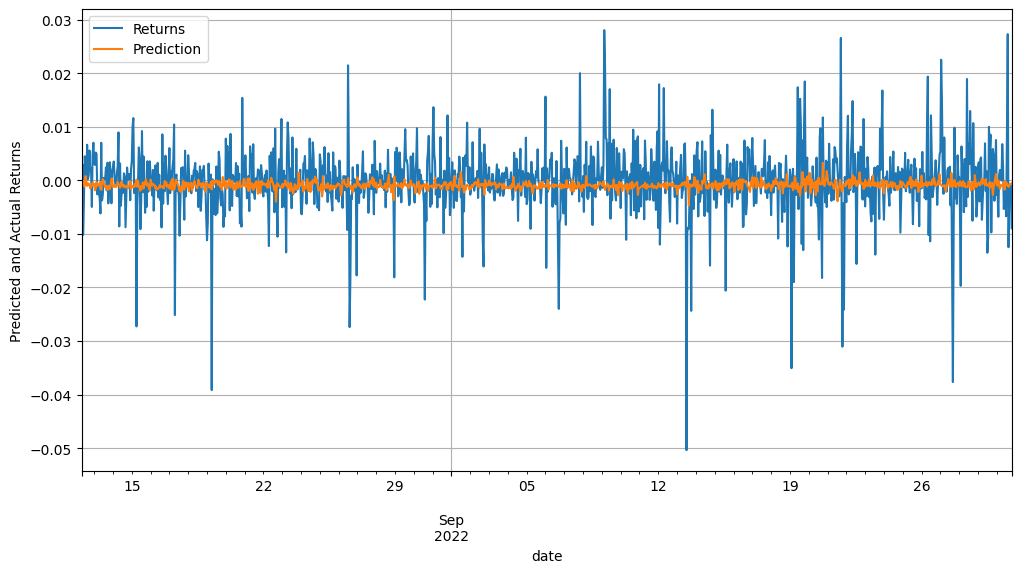

In [15]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df_res.plot(x="Date", y="Ret", label="Returns", ax=ax)
df_res.plot(x="Date", y="Pred", label="Prediction", ax=ax)
plt.xlabel("date")
plt.ylabel("Predicted and Actual Returns")
plt.grid()
plt.show()

In [16]:
df_res["Positions"] = np.where(df_res["Pred"] > 0.0, 1, -1)
df_res["Positions_shift"] = df_res["Positions"].shift(1)
df_res["Strat_ret"] = df_res["Positions"].shift(1) * df_res["Ret"]
df_res["Positions_L"] = df_res["Positions"].shift(1)
df_res["Positions_L"][df_res["Positions_L"] == -1] = 0
df_res["Strat_ret_L"] = df_res["Positions_L"] * df_res["Ret"]

Final_Return_L = np.prod(1 + df_res["Strat_ret_L"]) - 1
Final_Return = np.prod(1 + df_res["Strat_ret"]) - 1
Buy_Return = np.prod(1 + df_res["Ret"]) - 1

print(
    "Strat Return Long Only =",
    np.round(Final_Return_L * 100, 2),
    "% ,",
    "Sharpe ratio =",
    np.round(
        np.sqrt(24.0 * 365.0)
        * np.mean(df_res["Strat_ret_L"])
        / np.std(df_res["Strat_ret_L"]),
        2,
    ),
)
print(
    "Strat Return =",
    np.round(Final_Return * 100, 2),
    "% ,",
    "Sharpe ratio =",
    np.round(
        np.sqrt(24.0 * 365.0)
        * np.mean(df_res["Strat_ret"])
        / np.std(df_res["Strat_ret"]),
        2,
    ),
)
print(
    "Buy and Hold Return =",
    np.round(Buy_Return * 100, 2),
    "%, ",
    "Sharpe ratio =",
    np.round(np.sqrt(24.0 * 365.0) * np.mean(df_res["Ret"]) / np.std(df_res["Ret"]), 2),
)

Strat Return Long Only = -5.6 % , Sharpe ratio = -2.67
Strat Return = 4.82 % , Sharpe ratio = 0.89
Buy and Hold Return = -18.67 %,  Sharpe ratio = -2.34


/tmp/ipykernel_44/2666742369.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res["Positions_L"][df_res["Positions_L"] == -1] = 0


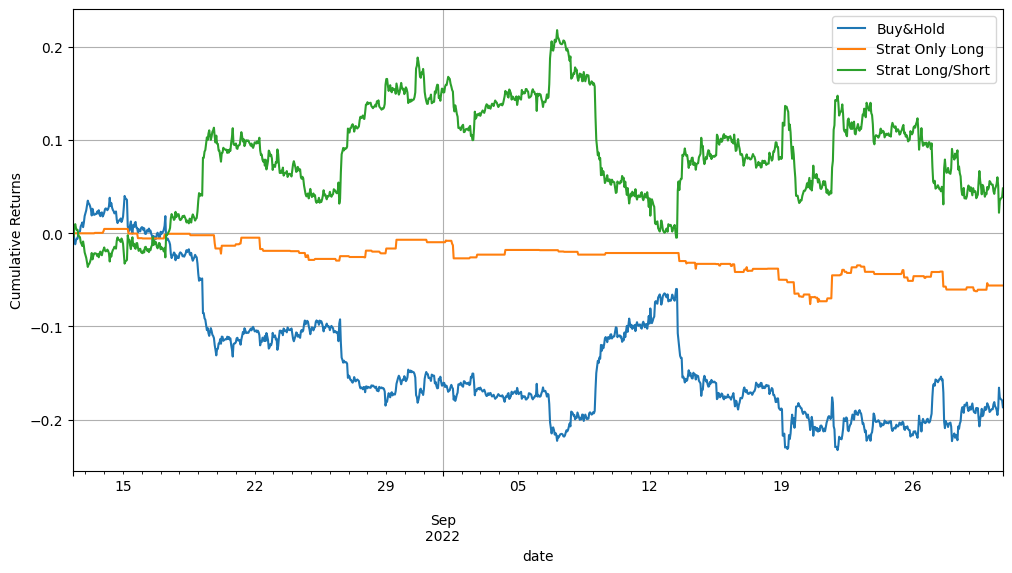

,Date,Pred,Ret,Positions,Positions_shift,Strat_ret,Positions_L,Strat_ret_L,CumRet,CumRet_L,bhRet,trade_bin
count,1188,1188.000000,1188.000000,1188.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1187.000000,1188.000000,1187.000000
mean,2022-09-06 01:30:00,-0.000879,-0.000155,-0.816498,-0.816344,0.000059,0.091828,-0.000047,0.082736,-0.025930,-0.137649,0.155013
min,2022-08-12 08:00:00,-0.004735,-0.050365,-1.000000,-1.000000,-0.028047,0.000000,-0.016800,-0.036132,-0.076005,-0.232680,0.000000
25%,2022-08-24 16:45:00,-0.001235,-0.002660,-1.000000,-1.000000,-0.002706,0.000000,-0.000000,0.043331,-0.038173,-0.187442,0.000000
50%,2022-09-06 01:30:00,-0.000928,0.000005,-1.000000,-1.000000,-0.000096,0.000000,0.000000,0.084821,-0.021515,-0.162404,0.000000
75%,2022-09-18 10:15:00,-0.000541,0.002628,-1.000000,-1.000000,0.002602,0.000000,0.000000,0.126358,-0.013338,-0.104442,0.000000
max,2022-09-30 19:00:00,0.003268,0.028047,1.000000,1.000000,0.050365,1.000000,0.026586,0.218015,0.004676,0.040084,1.000000
std,NaN,0.000692,0.006192,0.577591,0.577810,0.006197,0.288905,0.001659,0.055235,0.018624,0.067938,0.362069


In [17]:
import matplotlib.pyplot as plt

df_res["CumRet"] = df_res["Strat_ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)
df_res["CumRet_L"] = (
    df_res["Strat_ret_L"].expanding().apply(lambda x: np.prod(1 + x) - 1)
)
df_res["bhRet"] = df_res["Ret"].expanding().apply(lambda x: np.prod(1 + x) - 1)

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
df_res.plot(x="Date", y="bhRet", label="Buy&Hold", ax=ax)
df_res.plot(x="Date", y="CumRet_L", label="Strat Only Long", ax=ax)
df_res.plot(x="Date", y="CumRet", label="Strat Long/Short", ax=ax)
plt.xlabel("date")
plt.ylabel("Cumulative Returns")
plt.grid()
plt.show()

df_res["trade_bin"] = df_res["Positions"].diff().abs()
df_res["trade_bin"] = df_res["trade_bin"] / 2
df_res.describe()

## **5. CONCLUSION**

In this notebook, we have outlined and implemented the Walk Forward method using custom backtest statistics for strategies based on Deep Learning models. 

With this, we finalize our journey in Deep Learning for Finance. Congrats! 

We hope that all the methods described in the course help you develop your skills as an expert in Quantitative Finance. The field of Deep Learning is constantly evolving, so do not forget to keep track of any new developments!